# Calibrate image-to-stage

Figure out how the camera's X and Y axes match the stage's X and Y axes.



## Step 1: Configure

Fill in the cell below:

- `session_id`: a name for this run (the date works well).
- `reference_objective`: which objective is on the microscope.
- `stage_move_um`: how far the stage should move during the test, in micrometers.

`SESSIONS_ROOT` is where this run's images and reports are saved.
`LIVE_ROOT` is where the active calibration lives. Edit these two lines if
you want a different location.

Running this cell opens LAS X and prepares the session folder. Nothing is
acquired yet.


In [1]:
import _bootstrap
from pathlib import Path
from navigator_expert.calibration.workflows import image_to_stage as wf

SESSIONS_ROOT = Path(
    r"C:\ProgramData\MinicondaZMB\home\t.de\navigator_expert_calibration\sessions"
)
LIVE_ROOT = Path(
    r"C:\ProgramData\MinicondaZMB\home\t.de\navigator_expert_calibration\current_config"
)

session = wf.start_session(
    session_id="2026-05-22_scope_calibration",
    job_name="Overview",
    reference_objective="10x",
    stage_move_um=40.0,
    sessions_root=SESSIONS_ROOT,
)
print(session)

ImageToStageSession(session_id='2026-05-22_scope_calibration', paths=SessionPaths(session_dir=WindowsPath('C:/ProgramData/MinicondaZMB/home/t.de/navigator_expert_calibration/sessions/2026-05-22_scope_calibration'), configs_dir=WindowsPath('C:/ProgramData/MinicondaZMB/home/t.de/navigator_expert_calibration/sessions/2026-05-22_scope_calibration/configs'), reports_dir=WindowsPath('C:/ProgramData/MinicondaZMB/home/t.de/navigator_expert_calibration/sessions/2026-05-22_scope_calibration/reports'), notebooks_dir=WindowsPath('C:/ProgramData/MinicondaZMB/home/t.de/navigator_expert_calibration/sessions/2026-05-22_scope_calibration/notebooks'), data_dir=WindowsPath('C:/ProgramData/MinicondaZMB/home/t.de/navigator_expert_calibration/sessions/2026-05-22_scope_calibration/data/image_to_stage')), job_name='Overview', client=<PYLICamApiConnector.LasxApiClientPyModel object at 0x000002E7C3045AC0>, stage_cfg={'schema_version': 1, 'limits_um': {'x': [1000, 130000], 'y': [1000, 100000], 'z_galvo': [-200, 

## Step 2: Measure

The microscope takes three pictures: one at the home position, one after
moving +X, one after moving +Y. The notebook then figures out which axes
match and saves the result.

The figure below shows four candidate orientations. The winner is named at
the top -- that tile's images line up cleanly; the other three show
magenta/green ghosting because they are wrong.


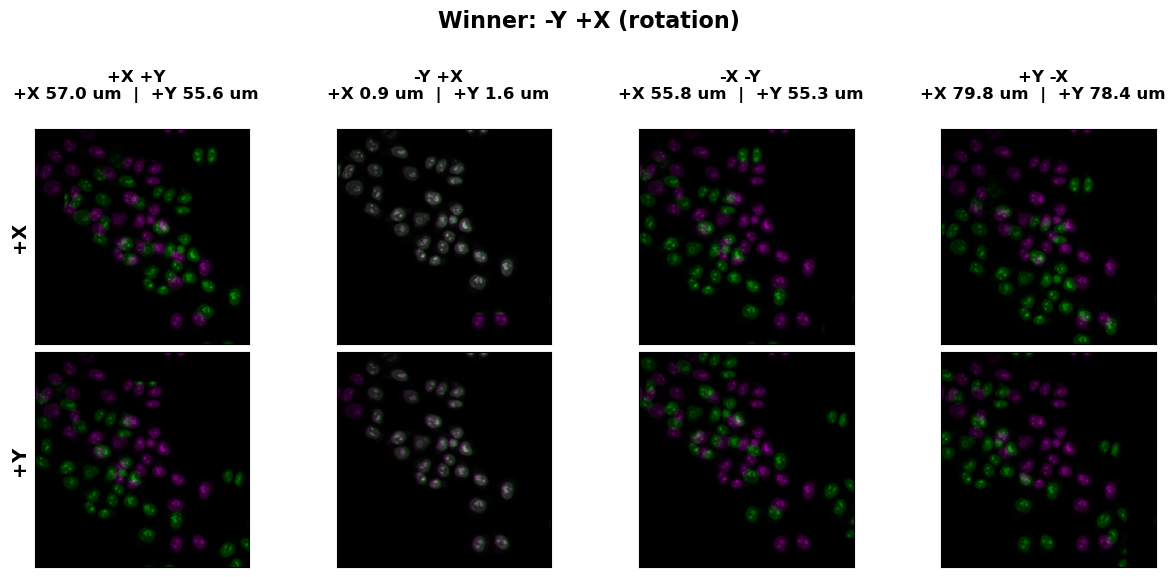

Image-to-stage calibration: OK

  Reference objective:  10x
  Stage move:           40.0 um
  Voting:               +X trusted (4/4),  +Y trusted (4/4)
  Orientation winner:   -Y +X  (90 deg CCW rotation)
  D4 residual:          0.05 um  (threshold 0.30 um)

  Staging config written:
    C:\ProgramData\MinicondaZMB\home\t.de\navigator_expert_calibration\sessions\2026-05-22_scope_calibration\configs\image_to_stage.json

  Run the promote cell below to copy this to the live config.


In [2]:
session = wf.measure(session)
summary = wf.save_and_visualize(session)

## Step 3 (optional): Make this the active calibration

Run this cell only if the figure above looks right. It copies the new
calibration to `LIVE_ROOT` and moves the old one to an archive.


In [3]:
from navigator_expert.calibration.workflows import promotion

promotion.promote_calibration(
    session,
    staging_name="image_to_stage.json",
    live_root=LIVE_ROOT,
)

{'source': 'C:\\ProgramData\\MinicondaZMB\\home\\t.de\\navigator_expert_calibration\\sessions\\2026-05-22_scope_calibration\\configs\\image_to_stage.json',
 'live_path': 'C:\\ProgramData\\MinicondaZMB\\home\\t.de\\navigator_expert_calibration\\current_config\\image_to_stage.json',
 'archived_previous': 'C:\\ProgramData\\MinicondaZMB\\home\\t.de\\navigator_expert_calibration\\current_config\\archive\\2026-05-22T23_22_41_02_00_image_to_stage.json'}